In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

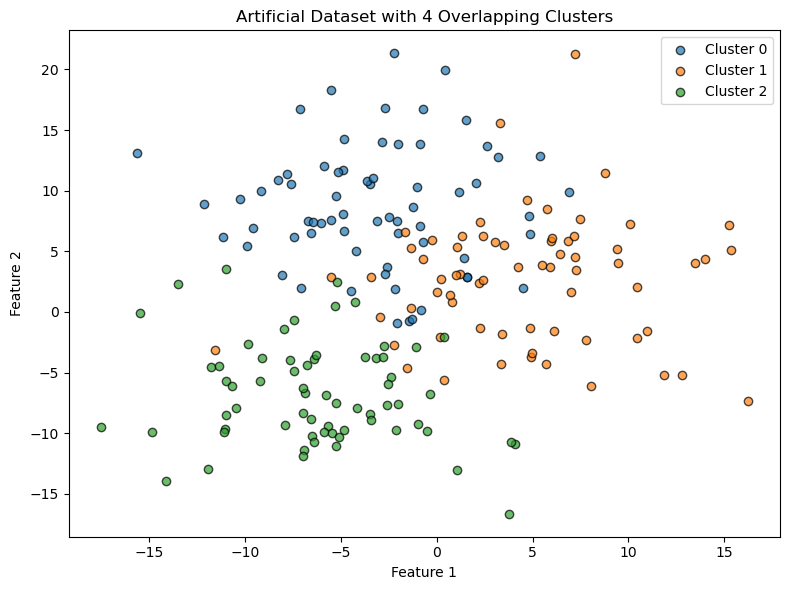

In [82]:
X, y = make_blobs(n_samples=200, centers=3, cluster_std=5, random_state=42)

plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X[y == label, 0], X[y == label, 1], label=f'Cluster {label}', alpha=0.7, edgecolors='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Artificial Dataset with 4 Overlapping Clusters')
plt.legend()
plt.tight_layout()
plt.show()

In [83]:
def rbf_kernel(X1, X2, gamma=0.5):
    sq_dists = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1).reshape(1, -1) - 2 * X1 @ X2.T
    return np.exp(-gamma * sq_dists)

K = rbf_kernel(X, X, gamma=0.2)
df_K = pd.DataFrame(K, index=[f'point_{i}' for i in range(K.shape[0])], columns=[f'point_{i}' for i in range(K.shape[1])])
df_K.head()

,point_0,point_1,point_2,point_3,point_4,point_5,point_6,point_7,point_8,point_9,...,point_190,point_191,point_192,point_193,point_194,point_195,point_196,point_197,point_198,point_199
point_0,1.000000e+00,2.087160e-83,3.896104e-60,3.233004e-98,3.930315e-54,5.856252e-32,1.841978e-30,2.756830e-56,1.537974e-21,7.391178e-31,...,1.336836e-19,1.661672e-15,3.588229e-63,5.317119e-63,4.688556e-23,2.409961e-34,1.037638e-07,2.060221e-13,2.049103e-13,1.849549e-18
point_1,2.087160e-83,1.000000e+00,2.399219e-59,1.968160e-64,3.420820e-25,3.498393e-39,4.142813e-14,4.265215e-35,2.350283e-32,1.280571e-39,...,1.059825e-24,1.869730e-33,5.079800e-29,4.937563e-35,9.369965e-35,9.261260e-24,1.004120e-45,5.102583e-39,2.390743e-31,8.854955e-26
point_2,3.896104e-60,2.399219e-59,1.000000e+00,9.077463e-06,4.471918e-08,6.481341e-07,2.187429e-43,5.937279e-04,6.610336e-73,2.878331e-07,...,1.137191e-29,2.976096e-24,1.271284e-06,2.542924e-04,1.195647e-13,3.543297e-13,1.182623e-56,7.190000e-65,9.254751e-39,1.484306e-30
point_3,3.233004e-98,1.968160e-64,9.077463e-06,1.000000e+00,2.170327e-13,4.928374e-20,1.863547e-62,1.230671e-08,1.113288e-102,7.738136e-21,...,4.258742e-50,1.418526e-45,3.235891e-09,5.003925e-07,1.611805e-30,1.717911e-25,2.105071e-88,5.101548e-96,1.258170e-63,1.284709e-51
point_4,3.930315e-54,3.420820e-25,4.471918e-08,2.170327e-13,1.000000e+00,9.909444e-05,2.899640e-19,1.385036e-01,1.605271e-44,4.219781e-05,...,4.053396e-14,1.076018e-13,3.271801e-01,7.512762e-02,2.035339e-07,2.453371e-03,1.052809e-38,1.183959e-41,3.132998e-22,4.689212e-15


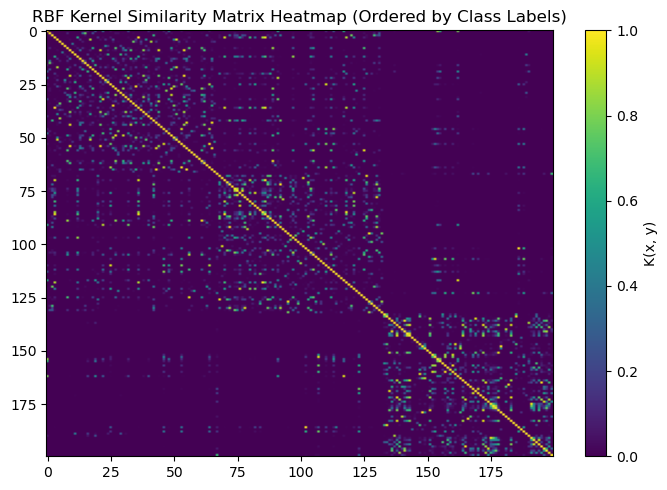

In [84]:
order = np.argsort(y)
K_ordered = K[np.ix_(order, order)]

plt.figure(figsize=(7, 5))
plt.imshow(K_ordered, cmap='viridis', aspect='auto')
plt.colorbar(label='K(x, y)')
plt.title('RBF Kernel Similarity Matrix Heatmap (Ordered by Class Labels)')
plt.tight_layout()
plt.show()